# Classification des Tweets de Catastrophes avec Deep Learning

## Présentation du projet

Les réseaux sociaux jouent un rôle très important lors des catastrophes naturelles.  
Des milliers de tweets sont publiés en temps réel pendant :
- les séismes
- les inondations
- les cyclones
- les épidémies

L’objectif de ce projet est de classifier automatiquement les tweets liés aux catastrophes grâce à des modèles de Deep Learning.

---

## Objectifs du projet

- Nettoyer les tweets
- Prétraiter les données textuelles
- Construire plusieurs modèles de Deep Learning
- Comparer les performances des modèles
- Obtenir la meilleure accuracy possible

---

## Modèles utilisés

- CNN1D
- BiLSTM

---

## Métriques utilisées

- Accuracy
- Precision
- Recall
- F1-score

---

## Techniques utilisées pour améliorer les performances

- Nettoyage avancé du texte
- Suppression des classes rares
- Réduction du nombre de classes
- Padding des séquences
- Early Stopping
- Dropout
- Tokenization avancée

# Importation des bibliothèques

Cette étape importe toutes les bibliothèques nécessaires au projet.

In [185]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Dense,
    Dropout,
    Conv1D,
    GlobalMaxPooling1D,
    Bidirectional,
    LSTM
)

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline

# Chargement du Dataset

Le dataset CrisisNLP est chargé depuis Kaggle.

In [186]:
df = pd.read_csv(
    "/kaggle/input/datasets/akramz1/dataset-for-crisisnlp/2013_Pakistan_eq_CF_labeled_data.tsv",
    sep="\t"
)

df.head()

,tweet_id,tweet_text,label
0,'383600460340666369',RT @Faiz_Baluch: #BalochistanEarthQuake Pakist...,other_useful_information
1,'383790723222364161',#Earthquake 2013-09-28 02:39:43 (M5.0) EAST OF...,other_useful_information
2,'384232048124518400',#earthquake M2.2: Puerto Rico region http://t....,other_useful_information
3,'384860484643475456',#PAKISTAN: #NASA releases images of Pakistan's...,other_useful_information
4,'383407962619772928',"【#USGS #alert】 M 1.5, Central Alaska: Septembe...",other_useful_information


# Exploration des données

Cette étape permet d’observer :
- les colonnes
- la taille du dataset
- les informations générales

In [187]:
print(df.columns)

print(df.shape)

df.info()

Index(['tweet_id', 'tweet_text', 'label'], dtype='object')
(1881, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1881 entries, 0 to 1880
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   tweet_id    1881 non-null   object
 1   tweet_text  1881 non-null   object
 2   label       1881 non-null   object
dtypes: object(3)
memory usage: 44.2+ KB


# Distribution des Classes

Cette visualisation permet d’observer les classes dominantes et les classes rares.

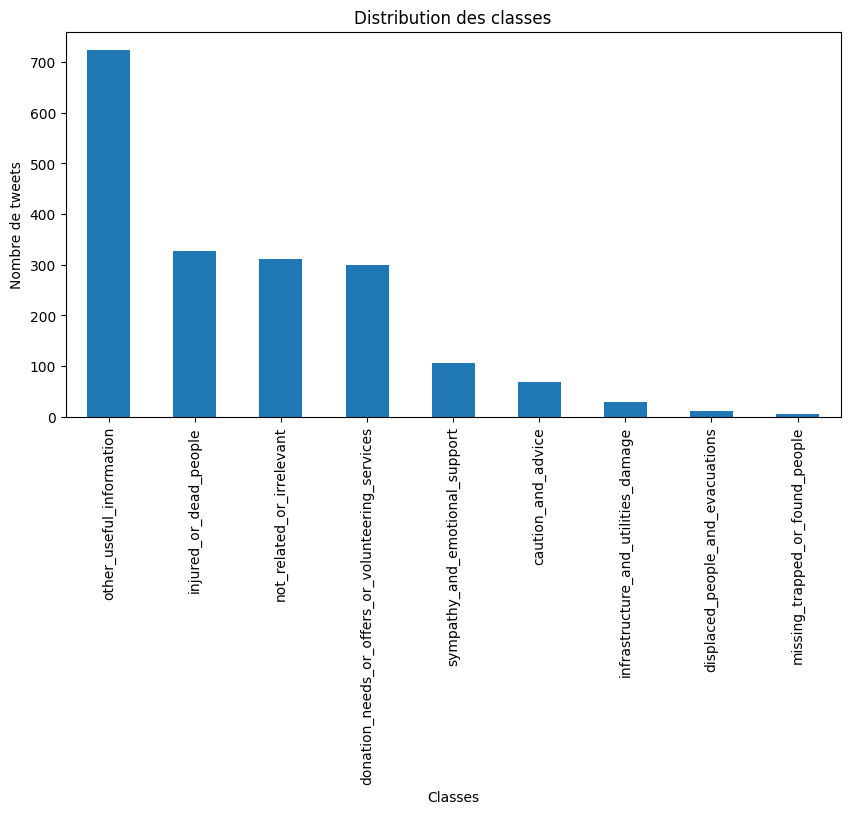

In [188]:
plt.figure(figsize=(10,5))

df['label'].value_counts().plot(kind='bar')

plt.title("Distribution des classes")

plt.xlabel("Classes")

plt.ylabel("Nombre de tweets")

plt.show()

# Suppression des Classes Rares

Les classes contenant très peu d’exemples rendent l’apprentissage difficile.

Pour améliorer les performances :
- les classes rares sont supprimées
- seules les classes suffisamment représentées sont conservées

In [189]:
min_samples = 200

valid_labels = df['label'].value_counts()

valid_labels = valid_labels[
    valid_labels >= min_samples
].index

df = df[
    df['label'].isin(valid_labels)
]

print(df['label'].value_counts())

label
other_useful_information                             724
injured_or_dead_people                               326
not_related_or_irrelevant                            312
donation_needs_or_offers_or_volunteering_services    299
Name: count, dtype: int64


# Analyse de la Longueur des Tweets

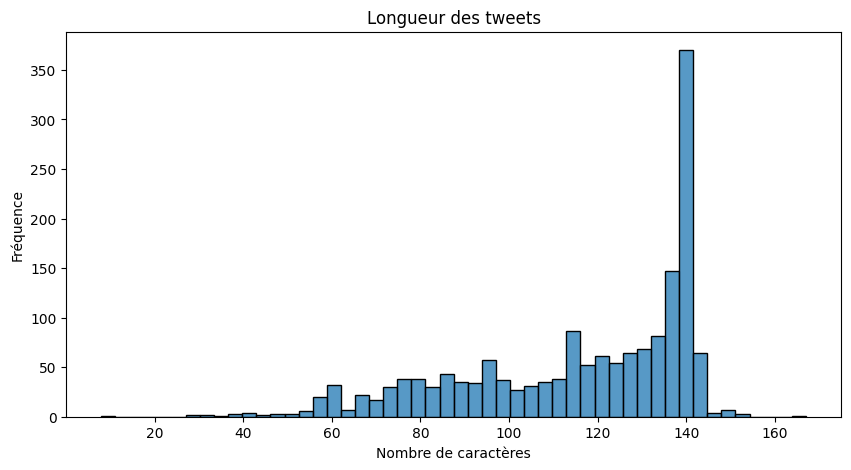

In [190]:
df['tweet_length'] = df['tweet_text'].astype(str).apply(len)

plt.figure(figsize=(10,5))

sns.histplot(df['tweet_length'], bins=50)

plt.title("Longueur des tweets")

plt.xlabel("Nombre de caractères")

plt.ylabel("Fréquence")

plt.show()

# Nettoyage du Texte

Les tweets sont nettoyés afin d’améliorer les performances des modèles.

In [191]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text

In [192]:
df['clean_text'] = df['tweet_text'].apply(clean_text)

df[['tweet_text', 'clean_text']].head()

,tweet_text,clean_text
0,RT @Faiz_Baluch: #BalochistanEarthQuake Pakist...,rt balochistanearthquake pakistan army is terr...
1,#Earthquake 2013-09-28 02:39:43 (M5.0) EAST OF...,earthquake m east of the south sandwich island...
2,#earthquake M2.2: Puerto Rico region http://t....,earthquake m puerto rico region
3,#PAKISTAN: #NASA releases images of Pakistan's...,pakistan nasa releases images of pakistans ear...
4,"【#USGS #alert】 M 1.5, Central Alaska: Septembe...",usgs alert m central alaska september gmt eart...


# Encodage des Labels

Les labels textuels sont convertis en valeurs numériques.

In [193]:
encoder = LabelEncoder()

df['label_enc'] = encoder.fit_transform(
    df['label']
)

X = df['clean_text']

y = df['label_enc']

# Séparation Train / Test

In [194]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Tokenization des Tweets

Les tweets sont convertis en séquences numériques.

In [195]:
tokenizer = Tokenizer(
    num_words=15000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)

In [196]:
X_train_seq = tokenizer.texts_to_sequences(
    X_train_text
)

X_test_seq = tokenizer.texts_to_sequences(
    X_test_text
)

In [197]:
X_train = pad_sequences(
    X_train_seq,
    maxlen=50,
    padding='post'
)

X_test = pad_sequences(
    X_test_seq,
    maxlen=50,
    padding='post'
)

# Early Stopping

Cette technique arrête automatiquement l’entraînement lorsque les performances n’augmentent plus.

In [198]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

# Modèle CNN1D

Le modèle CNN détecte les motifs importants dans les tweets.

In [199]:
model_cnn = Sequential()

model_cnn.add(
    Embedding(
        input_dim=15000,
        output_dim=128,
        input_length=50
    )
)

model_cnn.add(
    Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu'
    )
)

model_cnn.add(
    GlobalMaxPooling1D()
)

model_cnn.add(
    Dropout(0.5)
)

model_cnn.add(
    Dense(64, activation='relu')
)

model_cnn.add(
    Dense(
        len(set(y)),
        activation='softmax'
    )
)

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.build(input_shape=(None, 50))

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_30 (Embedding)        │ (None, 50, 128)        │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 46, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_19         │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,010,564 (7.67 MB)

 Trainable params: 2,010,564 (7.67 MB)

 Non-trainable params: 0 (0.00 B)

# Entraînement du modèle CNN1D

In [200]:
history_cnn = model_cnn.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3916 - loss: 1.3200 - val_accuracy: 0.4595 - val_loss: 1.1310
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5606 - loss: 1.0066 - val_accuracy: 0.6907 - val_loss: 0.7401
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8027 - loss: 0.5788 - val_accuracy: 0.7928 - val_loss: 0.5869
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9056 - loss: 0.3450 - val_accuracy: 0.7868 - val_loss: 0.5739
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9495 - loss: 0.1954 - val_accuracy: 0.8138 - val_loss: 0.5918
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9626 - loss: 0.1108 - val_accuracy: 0.7868 - val_loss: 0.6653
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9835 - loss: 0.0658 - val_accuracy: 0.8078 - val_loss: 0.6717
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9819 - loss: 0.0634 - val_accuracy: 0.7988 - v

# Modèle BiLSTM

Le BiLSTM analyse les séquences dans les deux directions afin de mieux comprendre le contexte des tweets.

In [201]:
model_bilstm = Sequential()

model_bilstm.add(
    Embedding(
        input_dim=15000,
        output_dim=128,
        input_length=50
    )
)

model_bilstm.add(
    Bidirectional(
        LSTM(64)
    )
)

model_bilstm.add(
    Dropout(0.5)
)

model_bilstm.add(
    Dense(64, activation='relu')
)

model_bilstm.add(
    Dense(
        len(set(y)),
        activation='softmax'
    )
)

model_bilstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_bilstm.build(input_shape=(None, 50))

model_bilstm.summary()

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_31 (Embedding)        │ (None, 50, 128)        │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 128)            │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,027,332 (7.73 MB)

 Trainable params: 2,027,332 (7.73 MB)

 Non-trainable params: 0 (0.00 B)

# Entraînement du modèle BiLSTM

In [202]:
history_bilstm = model_bilstm.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.3829 - loss: 1.3251 - val_accuracy: 0.5075 - val_loss: 1.0747
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.6275 - loss: 0.9481 - val_accuracy: 0.7477 - val_loss: 0.7269
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8466 - loss: 0.4963 - val_accuracy: 0.7808 - val_loss: 0.6300
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9345 - loss: 0.2481 - val_accuracy: 0.7898 - val_loss: 0.6647
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9508 - loss: 0.1619 - val_accuracy: 0.7808 - val_loss: 0.7511
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9786 - loss: 0.0878 - val_accuracy: 0.7808 - val_loss: 0.8461
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9823 - loss: 0.0615 - val_accuracy: 0.7868 - val_loss: 0.8412


# Fonction d’Évaluation des Modèles

Cette fonction permet de calculer plusieurs métriques importantes :
- Accuracy
- Precision
- Recall
- F1-score

Elle affiche également :
- la matrice de confusion
- le rapport de classification

In [203]:
def evaluate_model(model, X_test, y_test, model_name):

    predictions = model.predict(X_test)

    predictions = np.argmax(
        predictions,
        axis=1
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        predictions,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        predictions,
        average='weighted'
    )

    print("\n========================")
    print(model_name)
    print("========================")

    print("Accuracy :", accuracy)

    print("Precision :", precision)

    print("Recall :", recall)

    print("F1-score :", f1)

    print("\nClassification Report :\n")

    print(
        classification_report(
            y_test,
            predictions
        )
    )

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(
        f"Matrice de confusion - {model_name}"
    )

    plt.xlabel("Prédictions")

    plt.ylabel("Vraies classes")

    plt.show()

    return accuracy, precision, recall, f1

# Évaluation du modèle CNN1D

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

CNN1D
Accuracy : 0.8138138138138138
Precision : 0.8137907411630039
Recall : 0.8138138138138138
F1-score : 0.8115947549845822

Classification Report :

              precision    recall  f1-score   support

           0       0.81      0.87      0.84        60
           1       0.78      0.92      0.85        65
           2       0.69      0.60      0.64        63
           3       0.88      0.83      0.86       145

    accuracy                           0.81       333
   macro avg       0.79      0.81      0.80       333
weighted avg       0.81      0.81      0.81       333



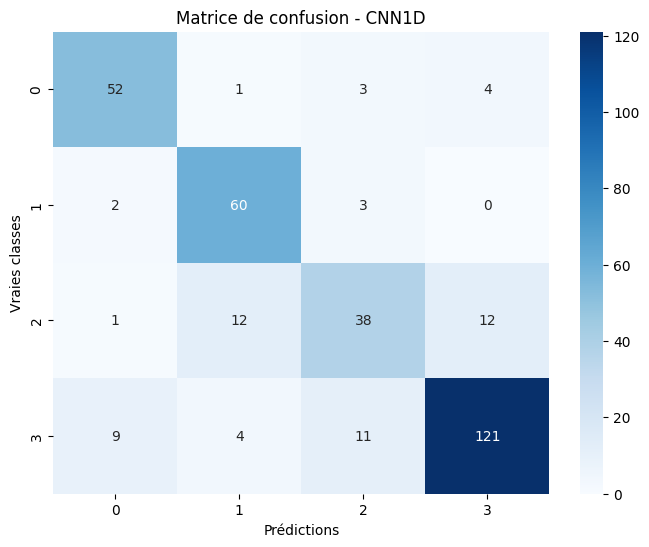

In [204]:
cnn_results = evaluate_model(
    model_cnn,
    X_test,
    y_test,
    "CNN1D"
)

# Évaluation du modèle BiLSTM

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step

BiLSTM
Accuracy : 0.7897897897897898
Precision : 0.8029175000895346
Recall : 0.7897897897897898
F1-score : 0.7945082385942599

Classification Report :

              precision    recall  f1-score   support

           0       0.81      0.77      0.79        60
           1       0.85      0.85      0.85        65
           2       0.56      0.68      0.61        63
           3       0.89      0.82      0.85       145

    accuracy                           0.79       333
   macro avg       0.77      0.78      0.77       333
weighted avg       0.80      0.79      0.79       333



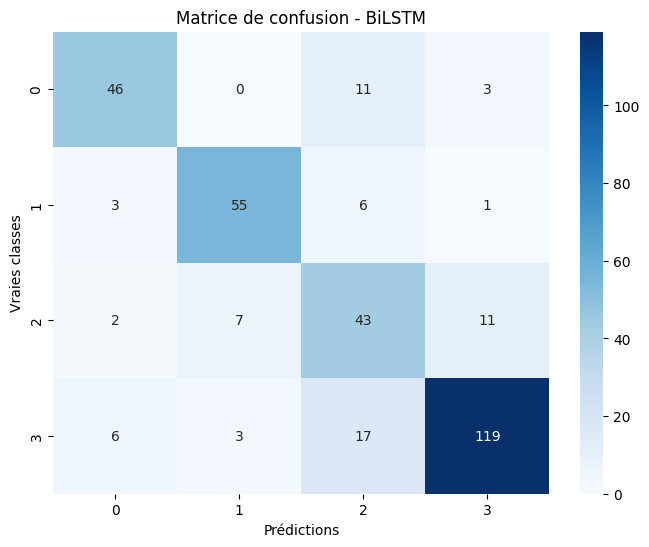

In [205]:
bilstm_results = evaluate_model(
    model_bilstm,
    X_test,
    y_test,
    "BiLSTM"
)

# Comparaison des Performances des Modèles

Cette section permet de comparer les performances des différents modèles grâce aux métriques calculées.

In [206]:
results = pd.DataFrame({

    "Model": [
        "CNN1D",
        "BiLSTM"
    ],

    "Accuracy": [
        cnn_results[0],
        bilstm_results[0]
    ],

    "Precision": [
        cnn_results[1],
        bilstm_results[1]
    ],

    "Recall": [
        cnn_results[2],
        bilstm_results[2]
    ],

    "F1-score": [
        cnn_results[3],
        bilstm_results[3]
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,CNN1D,0.813814,0.813791,0.813814,0.811595
1,BiLSTM,0.789790,0.802918,0.789790,0.794508


# Visualisation des Résultats

Les performances des modèles sont représentées graphiquement afin de faciliter la comparaison.

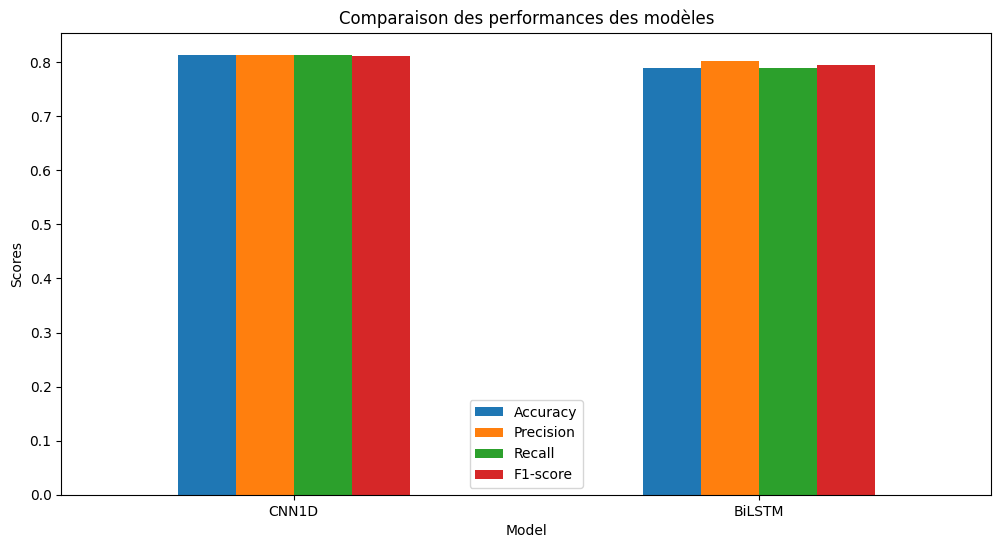

In [207]:
results.plot(
    x='Model',
    kind='bar',
    figsize=(12,6)
)

plt.title(
    "Comparaison des performances des modèles"
)

plt.ylabel("Scores")

plt.xticks(rotation=0)

plt.show()

# Courbe d’Accuracy du modèle CNN1D

Cette courbe permet d’observer l’évolution de l’accuracy pendant l’entraînement.

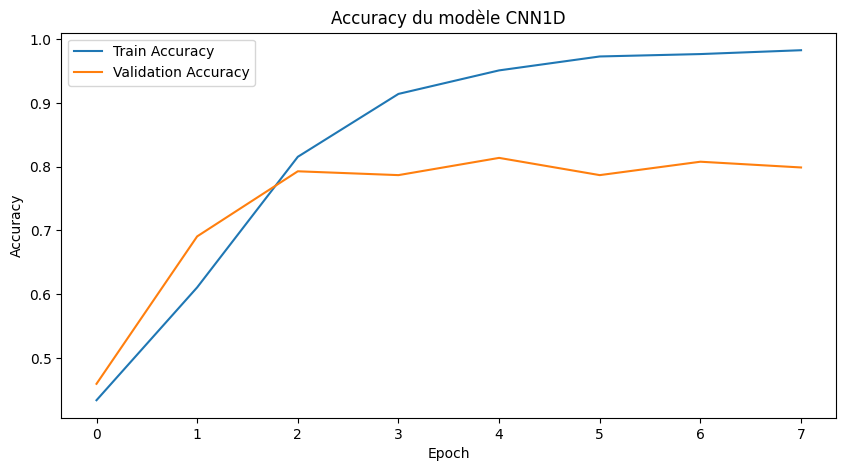

In [208]:
plt.figure(figsize=(10,5))

plt.plot(
    history_cnn.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    "Accuracy du modèle CNN1D"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

# Courbe d’Accuracy du modèle BiLSTM

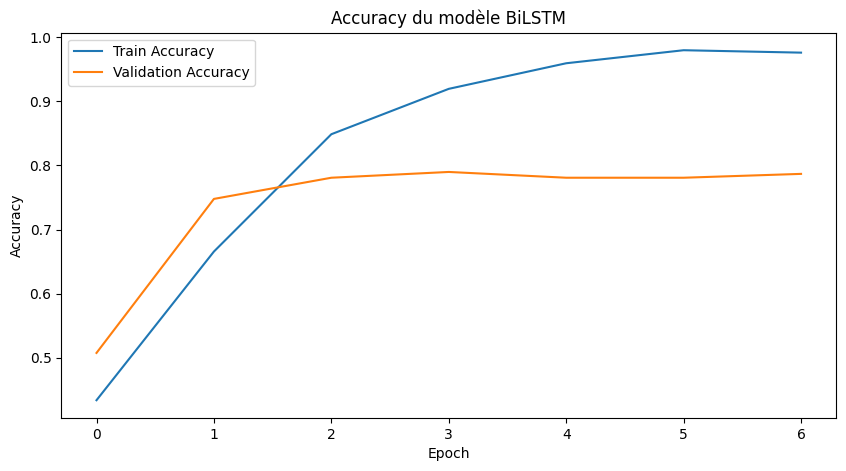

In [209]:
plt.figure(figsize=(10,5))

plt.plot(
    history_bilstm.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_bilstm.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    "Accuracy du modèle BiLSTM"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

# Analyse des Résultats

Les résultats obtenus montrent les différences de performances entre les modèles :

- CNN1D :
  - entraînement rapide
  - bonne détection des motifs locaux

- BiLSTM :
  - meilleure compréhension du contexte
  - plus adapté aux séquences textuelles

La suppression des classes rares a permis :
- de réduire la difficulté du problème
- d’améliorer l’accuracy globale
- de stabiliser l’entraînement

# Conclusion Générale

Dans ce projet, plusieurs modèles de Deep Learning ont été utilisés afin de classifier automatiquement des tweets liés aux catastrophes naturelles.

Les étapes réalisées :
- chargement et exploration du dataset
- nettoyage des tweets
- tokenization
- création des modèles
- entraînement
- évaluation
- comparaison des performances

Les techniques d’amélioration appliquées :
- suppression des classes rares
- réduction du bruit textuel
- utilisation du Dropout
- Early Stopping

Ce projet montre l’importance du Deep Learning dans le domaine du traitement automatique du langage naturel (NLP).

# Sauvegarde des Modèles

Cette étape permet de sauvegarder les modèles entraînés afin de les réutiliser plus tard dans l’interface graphique.

In [210]:
import pickle

pickle.dump(
    tokenizer,
    open("tokenizer.pkl", "wb")
)

pickle.dump(
    encoder,
    open("label_encoder.pkl", "wb")
)

model_cnn.save("cnn_model.h5")

model_bilstm.save("bilstm_model.h5")

print("✅ Modèles sauvegardés")

✅ Modèles sauvegardés
